# Monte Carlo simulation
***
This is a monte carlo style simulation, based on a random sampling of events, in this case, randomly-generated sheep eating and grass growing.

## Imports
***

In [2]:
import random
import numpy as np
from matplotlib import pyplot as plt
import scipy as sp

## Rate constants
***
The experimentally measured values for k and R.

In [3]:
R = 0.00888
K = 0.00772

Now that we have these values, we can plug them into the formula we derived earlier:

$D=\frac{k}{2R}=\frac{0.00772}{2*0.00888}=0.434$

According to the theory, this should be the optimal density of sheep.

## The simulation
***
How much grass is eaten on each frame? Each sheep has a chance R to attempt eating, and each attempt has a chance G to succeed. So the amount of grass eaten is a binomial random variable with n = sheep and p = R * G.

How much grass is eaten? Let's go back to the logistic derivative:

$G'=kG(1-G)$

This is going to be a little complicated. Here, G is the fraction of the pasture that is covered in grass. We can instead discuss the total area of grass in the pasture by multiplying by the pasture area:

$AG'=AkG(1-G)$

Let's separate this into a couple terms:

$AG'=k*(AG)*(1-G)$

k, of course, is just a constant. AG is the total number of grass blocks in the pasture. AG' is the expected number of grass blocks which grow in one second. And (1-G) is the fraction of the pasture which is grassless. This gives us some insight into how we can build a monte carlo model for grass growth. We can assume a binomial distribution, like we did for sheep, with n = AG and p = k(1-g).
***
We'll be assuming a 1000-block pasture. We'll define a function that takes the sheep population as an input so we can test whatever sheep density we want. We'll also let the function take as an input the number of seconds to simulate.

In [4]:
def monteCarlo(sheep_num, iter):

    g = 1000 #this is not G as in the grass density - this is the total number of grass blocks.

    eats_list = []
    grass_list = []
    
    for i in range(0, iter):
        #number of successful sheep eating attempts
        #binomial variate with success probability of R * grass fraction
        eats = sp.stats.binom.rvs(sheep_num, g/1000 * R)
        g -= eats

        #grass growth
        g += sp.stats.binom.rvs(g, K * (1 - g/1000))
    
        eats_list.append(eats)
        grass_list.append(g)
    return np.array(eats_list), np.array(grass_list)

Because we're dealing with a 1000-block pasture, the optimal sheep population should be 434. We'll run simulations with that population, and a few others:

In [12]:
iters = 10000

results = {"235": monteCarlo(235, iters),
           "335": monteCarlo(335, iters),
           "435": monteCarlo(435, iters),
           "535": monteCarlo(535, iters),
           "635": monteCarlo(635, iters)}

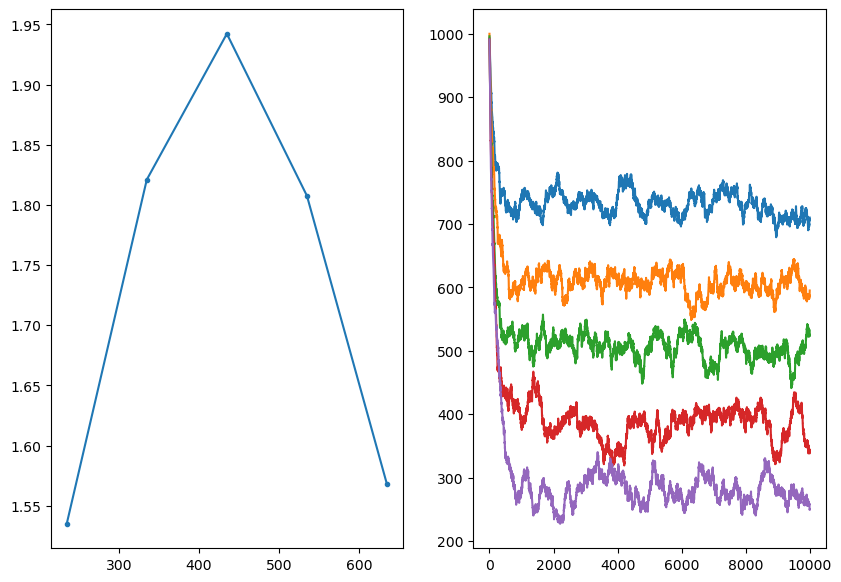

In [14]:
f, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 7))

#plot grass cover
for i in results.keys():
    axs[1].plot(results[i][1], "-", label=i)

#plot average sheep eating rate
axs[0].plot([int(j) for j in results.keys()], [np.average(results[j][0][5000:iters]) for j in results.keys()], ".-")

plt.show()